# 任务2_2 U-Net 语义分割（Carvana）
本任务使用 Carvana 车辆分割数据集训练 U-Net，实现二分类语义分割。整体流程：数据准备 → 模型 → 训练 → 评估 → 可视化。

## 1）数据集准备
- 将 Carvana 数据集解压到当前目录下的 carvana/
- 期望结构：
  - carvana/train/*.jpg
  - carvana/train_masks/*_mask.gif
- 如使用其它路径，请修改下面的 dataset_root

In [1]:
import os
import random
from pathlib import Path
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # 预防绘图崩溃
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# 数据集路径
dataset_root = Path("carvana")
train_dir = dataset_root / "train"
mask_dir = dataset_root / "train_masks"

if not train_dir.exists() or not mask_dir.exists():
    raise FileNotFoundError(
        "未找到 Carvana 数据集。请确认 carvana/train 和 carvana/train_masks 是否存在。"
    )

# 收集图片路径（支持 jpg/png/jpeg）
image_paths = []
for ext in ("*.jpg", "*.png", "*.jpeg"):
    image_paths.extend(train_dir.glob(ext))
image_paths = sorted(image_paths)

if len(image_paths) == 0:
    raise FileNotFoundError("未找到训练图片，请检查 carvana/train 目录。")


def find_mask_path(img_path):
    stem = img_path.stem
    candidates = [
        mask_dir / f"{stem}_mask.gif",
        mask_dir / f"{stem}_mask.png",
        mask_dir / f"{stem}_mask.jpg",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"未找到对应掩码: {img_path.name}")


class CarvanaDataset(Dataset):
    def __init__(self, image_paths, mask_dir, img_size=256, augment=False):
        self.image_paths = image_paths
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.augment = augment
        self.to_tensor = transforms.ToTensor()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = find_mask_path(img_path)

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.augment and random.random() < 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)
            mask = mask.transpose(Image.FLIP_LEFT_RIGHT)

        image = image.resize((self.img_size, self.img_size), resample=Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), resample=Image.NEAREST)

        image = self.to_tensor(image)
        mask = self.to_tensor(mask)
        mask = (mask > 0.5).float()
        return image, mask


# 划分训练/验证集
val_ratio = 0.2
indices = np.random.permutation(len(image_paths))
val_size = int(len(indices) * val_ratio)
val_idx = indices[:val_size]
train_idx = indices[val_size:]

train_paths = [image_paths[i] for i in train_idx]
val_paths = [image_paths[i] for i in val_idx]

batch_size = 8
train_ds = CarvanaDataset(train_paths, mask_dir, img_size=256, augment=True)
val_ds = CarvanaDataset(val_paths, mask_dir, img_size=256, augment=False)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"训练样本数: {len(train_ds)}，验证样本数: {len(val_ds)}")

device: cpu
训练样本数: 4071，验证样本数: 1017


## 2）数据可视化（样例）

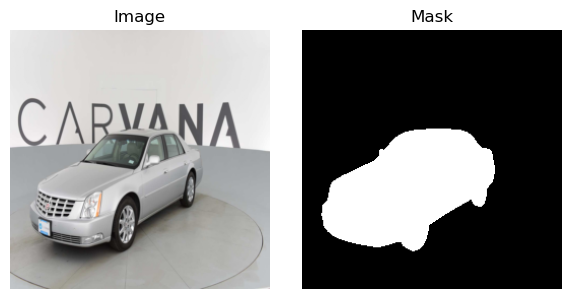

In [3]:
images, masks = next(iter(train_loader))
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(images[0].permute(1, 2, 0))
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(masks[0].squeeze(0), cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 3）构建 U-Net 模型

In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels),
        )

    def forward(self, x):
        return self.net(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diff_y = x2.size(2) - x1.size(2)
        diff_x = x2.size(3) - x1.size(3)
        x1 = F.pad(x1, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=64):
        super().__init__()
        self.inc = DoubleConv(in_channels, base_channels)
        self.down1 = Down(base_channels, base_channels * 2)
        self.down2 = Down(base_channels * 2, base_channels * 4)
        self.down3 = Down(base_channels * 4, base_channels * 8)
        self.down4 = Down(base_channels * 8, base_channels * 16)
        self.up1 = Up(base_channels * 16, base_channels * 8)
        self.up2 = Up(base_channels * 8, base_channels * 4)
        self.up3 = Up(base_channels * 4, base_channels * 2)
        self.up4 = Up(base_channels * 2, base_channels)
        self.outc = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

## 4）损失函数与评价指标

In [5]:
def dice_coeff(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2 * intersection + eps) / (union + eps)
    return dice.mean()


def iou_score(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean()


bce_loss = nn.BCEWithLogitsLoss()


def total_loss(logits, targets):
    return bce_loss(logits, targets) + (1 - dice_coeff(logits, targets))

## 5）训练与评估

In [6]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for images, masks in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        masks = masks.to(device)
        logits = model(images)
        loss = total_loss_fn(logits, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    for images, masks in tqdm(loader, desc="Val", leave=False):
        images = images.to(device)
        masks = masks.to(device)
        logits = model(images)
        loss = total_loss_fn(logits, masks)
        total_loss += loss.item() * images.size(0)
        total_dice += dice_coeff(logits, masks).item() * images.size(0)
        total_iou += iou_score(logits, masks).item() * images.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_dice / n, total_iou / n


def total_loss_fn(logits, targets):
    return total_loss(logits, targets)

In [10]:
model = UNet(in_channels=3, out_channels=1, base_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10
history = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_dice, val_iou = evaluate(model, val_loader, device)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)
    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | "
        f"IoU: {val_iou:.4f}"
    )

Train:   0%|          | 0/509 [00:00<?, ?it/s]

Val:   0%|          | 0/128 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.1494 | Val Loss: 0.1349 | Dice: 0.9439 | IoU: 0.9084


Train:   0%|          | 0/509 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 6）训练过程可视化

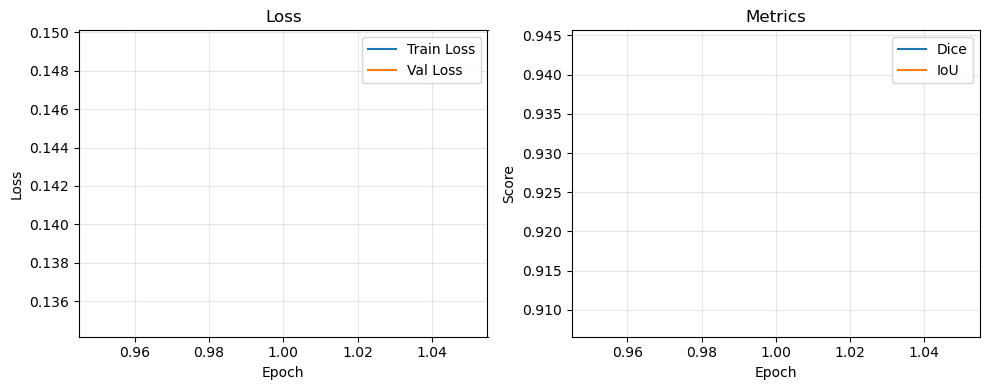

In [11]:
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["val_dice"], label="Dice")
axes[1].plot(epochs_range, history["val_iou"], label="IoU")
axes[1].set_title("Metrics")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7）结果可视化（预测示例）

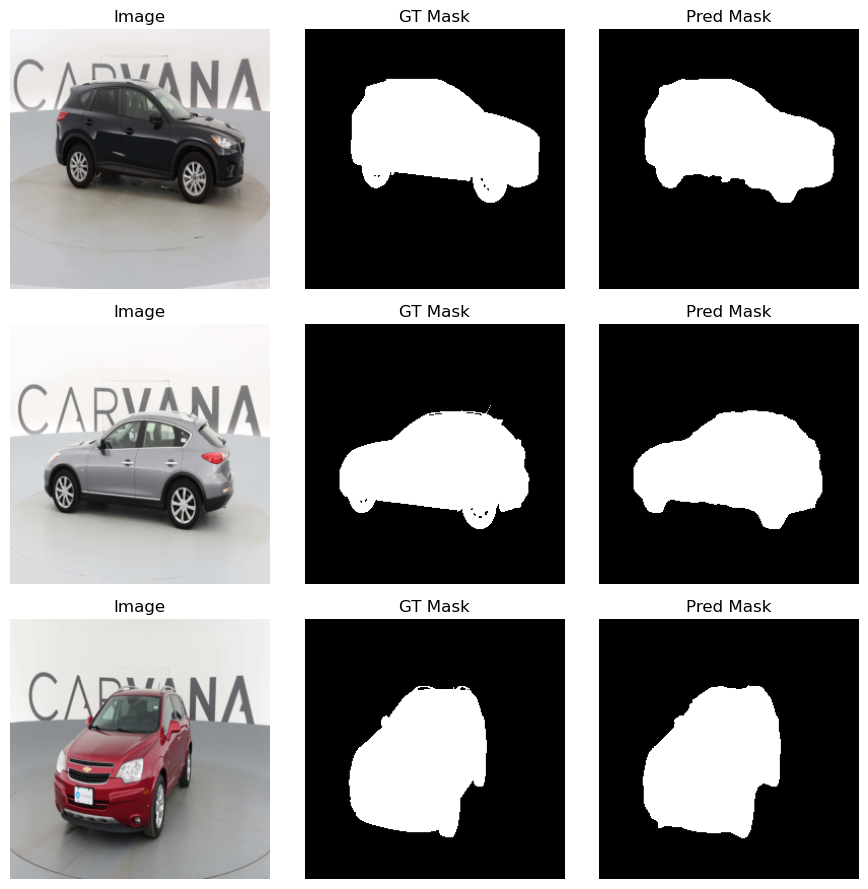

In [12]:
model.eval()
images, masks = next(iter(val_loader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = model(images)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

n = min(3, images.size(0))
fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
if n == 1:
    axes = [axes]

for i in range(n):
    axes[i][0].imshow(images[i].cpu().permute(1, 2, 0))
    axes[i][0].set_title("Image")
    axes[i][0].axis("off")

    axes[i][1].imshow(masks[i].cpu().squeeze(0), cmap="gray")
    axes[i][1].set_title("GT Mask")
    axes[i][1].axis("off")

    axes[i][2].imshow(preds[i].cpu().squeeze(0), cmap="gray")
    axes[i][2].set_title("Pred Mask")
    axes[i][2].axis("off")

plt.tight_layout()
plt.show()